In [ ]:
import json
import torch
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

In [46]:
# Load test dataset
TEST_FILE = "../1_data_preprocessing/dataset/empatheticdialogues/test.jsonl"
with open(TEST_FILE, 'r', encoding='utf-8') as f:
    raw_data = [json.loads(line) for line in f]

In [47]:
# Extract the latest user message from each conversation
prompts = []
for entry in raw_data:
    msgs = entry['messages']
    last_user_message = ""
    for msg in reversed(msgs):
        if msg['role'] == 'user':
            last_user_message = msg['content']
            break
    prompts.append(last_user_message)

print(f"Extracted {len(prompts)} user prompts from test.jsonl")


Extracted 2542 user prompts from test.jsonl


In [48]:
RESPONSE_FILE = "responses_llama3.2.csv"
df_responses = pd.read_csv(RESPONSE_FILE)
df_responses = df_responses[df_responses['response_text'].notnull()]  # remove invalid or missing responses
print(f"Loaded {len(df_responses)} valid model responses from CSV")

Loaded 2540 valid model responses from CSV


In [53]:
# Match and sample 500 examples
min_len = min(len(prompts), len(df_responses), 450)
prompts = prompts[:min_len]
model_responses = df_responses['response_text'].tolist()[:min_len]
print(f"Using {min_len} matched entries for evaluation.")

Using 450 matched entries for evaluation.


In [54]:
# Use Flan-T5-base as a lightweight EMRank judge
judge = pipeline("text2text-generation", model="google/flan-t5-base", device=-1)

Device set to use cpu


In [57]:
def build_prompt(patient_message, model_response, reference_response):
    return f"""
You are an empathy evaluation expert.
Given a patient message and two assistant responses, determine which one is more empathetic.

Patient Message:
{patient_message}

Response 1:
{reference_response}

Response 2:
{model_response}

Which response is more empathetic? Answer with: Response 1 or Response 2.
"""

In [59]:
results = []
for i in tqdm(range(len(prompts))):
    user_msg = prompts[i]
    model_resp = model_responses[i]

    # Use last assistant message as human reference
    msgs = raw_data[i]['messages']
    reference_resp = ""
    for msg in reversed(msgs):
        if msg['role'] == 'assistant':
            reference_resp = msg['content']
            break

    prompt = build_prompt(user_msg, model_resp, reference_resp)
    output = judge(prompt, max_new_tokens=50, do_sample=False)[0]['generated_text']

    if "Response 1" in output:
        winner = "human"
    elif "Response 2" in output:
        winner = "model"
    else:
        winner = "unclear"

    results.append({
        "index": i,
        "patient_message": user_msg,
        "model_response": model_resp,
        "human_response": reference_resp,
        "judge_output": output,
        "winner": winner
    })

100%|██████████| 450/450 [04:34<00:00,  1.64it/s]


In [60]:
# Convert results to DataFrame and display summary
df_results = pd.DataFrame(results)
df_results.to_csv("emrank_flan_t5_results.csv", index=False)

In [61]:
summary = df_results['winner'].value_counts().reindex(["human", "model", "unclear"], fill_value=0)
print("\nEMRank Evaluation Summary:")
print(summary)


EMRank Evaluation Summary:
winner
human       33
model      417
unclear      0
Name: count, dtype: int64


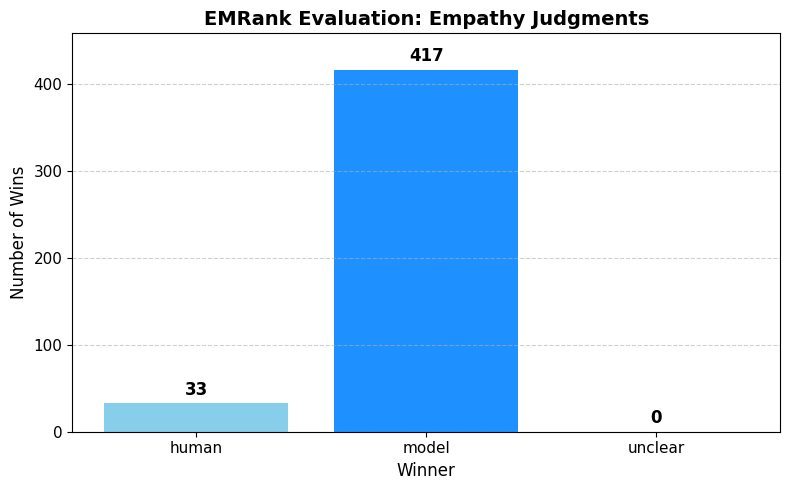

In [62]:
import matplotlib.pyplot as plt

# Count and reindex for consistency
summary = df_results['winner'].value_counts().reindex(["human", "model", "unclear"], fill_value=0)

# Plot with adjusted size and fonts
plt.figure(figsize=(8, 5))
bars = plt.bar(summary.index, summary.values, color=['skyblue', 'dodgerblue', 'lightgray'])

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(int(height)),
             ha='center', va='bottom', fontsize=12, weight='bold')

# Customize axes and grid
plt.title("EMRank Evaluation: Empathy Judgments", fontsize=14, weight='bold')
plt.ylabel("Number of Wins", fontsize=12)
plt.xlabel("Winner", fontsize=12)
plt.ylim(0, max(summary.values) * 1.1)  # Add headroom
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)


plt.tight_layout()
plt.show()
